In [3]:
from parse_dayahead_prices import list_components
print(list_components("Day-ahead_prices_240709_260311_Hour.xml"))



['Germany/Luxembourg', '∅ DE/LU neighbours', 'Belgium', 'Denmark 1', 'Denmark 2', 'France', 'Netherlands', 'Norway 2', 'Austria', 'Poland', 'Sweden 4', 'Switzerland', 'Czech Republic', 'DE/AT/LU', 'Northern Italy', 'Slovenia', 'Hungary']


from bsm2_python import BSM2CL
from tqdm import tqdm


bsm2_cl = BSM2CL()

# The custom DO setpoint for the BSM2 default aeration control
so4_ref = 1.5

for idx, _ in enumerate(tqdm(bsm2_cl.simtime)):
    bsm2_cl.step(idx, so4_ref)

# get the final performance of the plant
oci = bsm2_cl.get_final_performance()[-1]

Baseline (10 days): 100%|██████████| 14400/14400 [00:49<00:00, 291.36it/s]



First 5 rows:
                          ae_kw
dt                             
2024-07-09 01:00:00   60.185737
2024-07-09 01:01:00  130.645963
2024-07-09 01:02:00  166.197827
2024-07-09 01:03:00  178.974735
2024-07-09 01:04:00  186.304638

Last 5 rows:
                          ae_kw
dt                             
2024-07-19 00:55:00  170.387494
2024-07-19 00:56:00  169.295224
2024-07-19 00:57:00  172.385462
2024-07-19 00:58:00  175.661245
2024-07-19 00:59:00  181.087157

dtype of index : datetime64[us]
dtype of ae_kw : float64

ae_kw stats:
           ae_kw
count  14400.000
mean     163.427
std       30.303
min       60.186
25%      134.133
50%      171.128
75%      189.961
max      217.484

Plot saved to baseline_ae.png


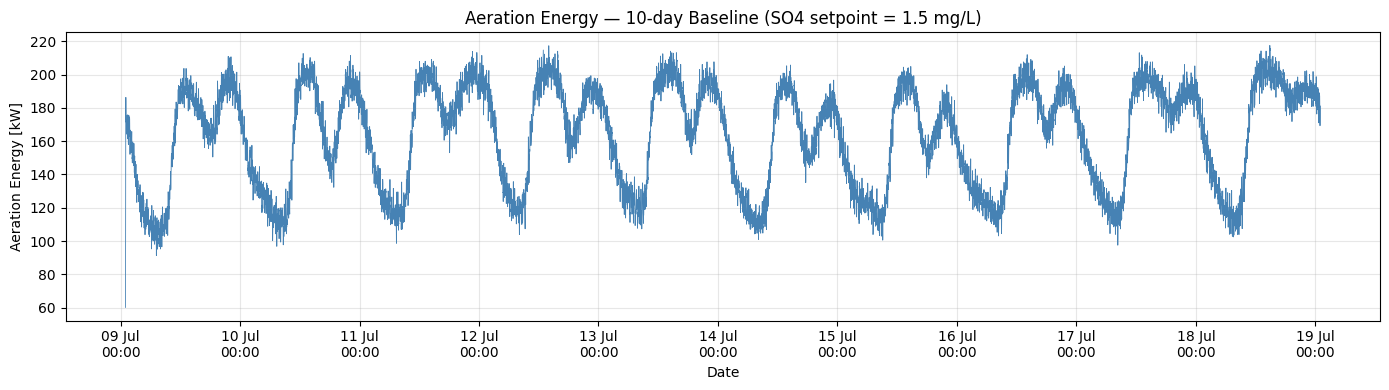

In [6]:
from bsm2_python import BSM2CL
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DAYS = 10
STEPS = DAYS * 24 * 60
SIM_START = pd.Timestamp("2024-07-09 01:00")  # match your XML start

bsm2_cl = BSM2CL()

records = []
for idx, _ in enumerate(tqdm(bsm2_cl.simtime[:STEPS], desc=f"Baseline ({DAYS} days)")):
    bsm2_cl.step(idx, 1.5)
    records.append({
        "dt":    SIM_START + pd.Timedelta(minutes=idx),
        "ae_kw": bsm2_cl.ae,
    })

df = pd.DataFrame(records).set_index("dt")
df.to_pickle("sim_baseline_ae.pkl")

# --- quick look at format ---
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print(f"\ndtype of index : {df.index.dtype}")
print(f"dtype of ae_kw : {df['ae_kw'].dtype}")
print(f"\nae_kw stats:")
print(df.describe().round(3))

# --- plot ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df["ae_kw"], linewidth=0.6, color="steelblue")
ax.set_title("Aeration Energy — 10-day Baseline (SO4 setpoint = 1.5 mg/L)")
ax.set_ylabel("Aeration Energy [kW]")
ax.set_xlabel("Date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("baseline_ae.png", dpi=150)
print("\nPlot saved to baseline_ae.png")

Baseline (10 days): 100%|██████████| 14400/14400 [00:53<00:00, 268.85it/s]



14,400 steps | index sample:
                          ae_kw  price      cost
dt                                              
2024-07-09 01:00:00   60.185737  95.96  0.096257
2024-07-09 01:01:00  130.645963  95.96  0.208946
2024-07-09 01:02:00  166.197827  95.96  0.265806
           ae_kw      price       cost
count  14400.000  14400.000  14400.000
mean     163.345     68.609      0.184
std       30.304     47.093      0.140
min       60.186    -73.960     -0.254
25%      134.030     41.032      0.115
50%      171.014     78.115      0.181
75%      189.876     92.960      0.256
max      217.466    227.600      0.753

Plot saved → baseline_ae.png


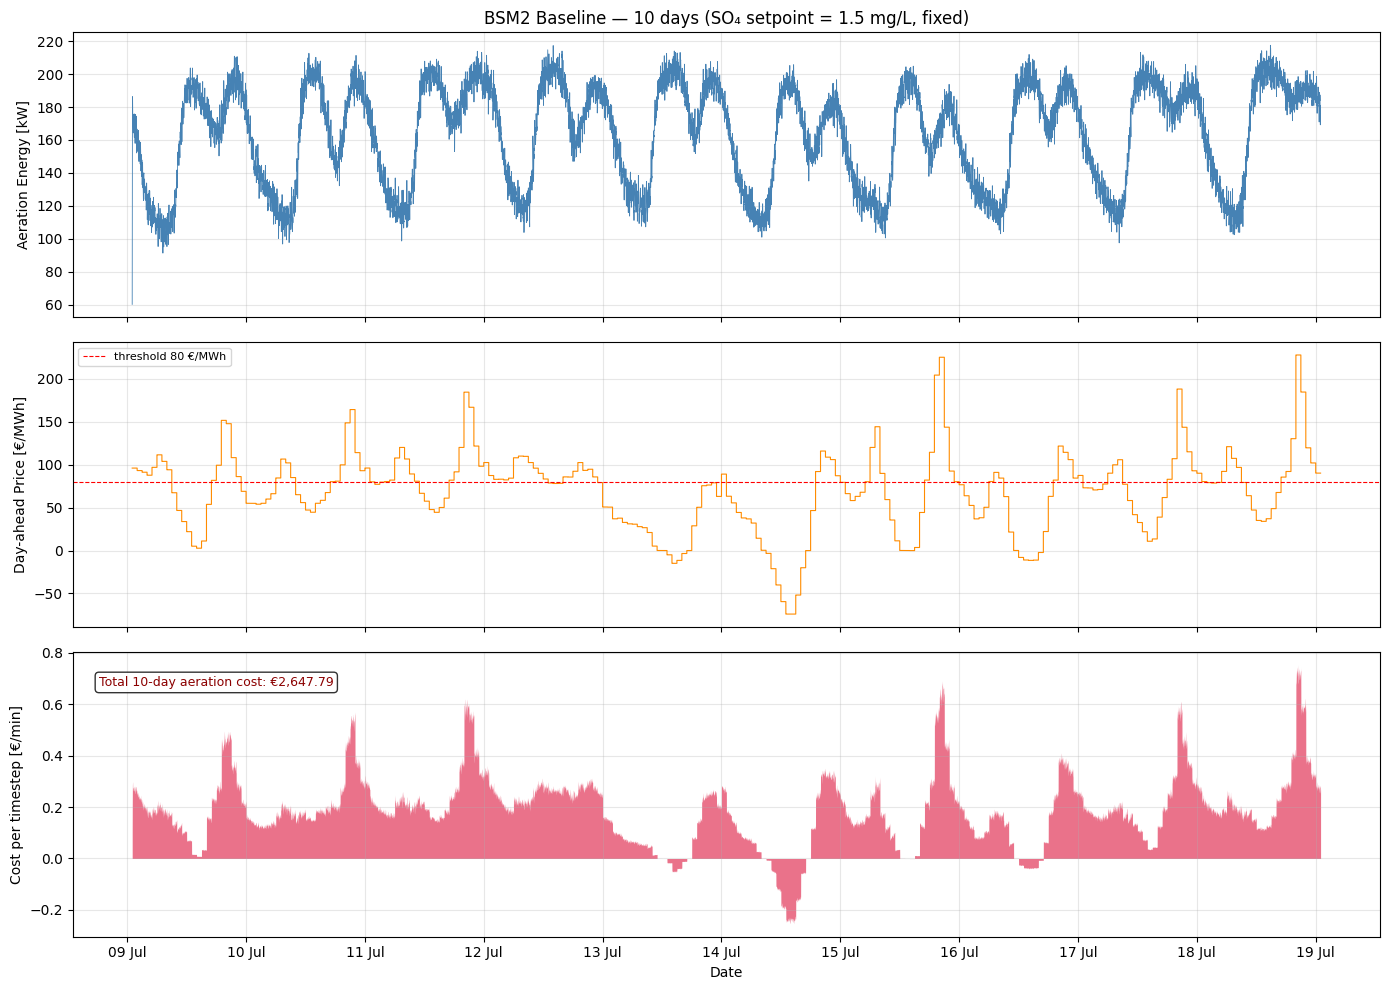

In [1]:
from bsm2_python import BSM2CL
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from parse_dayahead_prices import parse_dayahead_xml, get_price_for_timestep, price_to_cost

DAYS      = 10
STEPS     = DAYS * 24 * 60
SIM_START = pd.Timestamp("2024-07-09 01:00")

# --- load prices ---
prices = parse_dayahead_xml("Day-ahead_prices_240709_260311_Hour.xml")

# --- run baseline ---
bsm2_cl = BSM2CL()
records = []
for idx, _ in enumerate(tqdm(bsm2_cl.simtime[:STEPS], desc=f"Baseline ({DAYS} days)")):
    bsm2_cl.step(idx, 1.5)
    current_dt = SIM_START + pd.Timedelta(minutes=idx)
    price      = get_price_for_timestep(prices, current_dt)
    records.append({
        "dt":      current_dt,
        "ae_kw":   bsm2_cl.ae,
        "price":   price,
        "cost":    price_to_cost(bsm2_cl.ae, price),
    })

df = pd.DataFrame(records).set_index("dt")
df.to_pickle("sim_baseline_ae.pkl")

print(f"\n{len(df):,} steps | index sample:")
print(df.head(3).to_string())
print(df.describe().round(3))

# --- plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: aeration energy
axes[0].plot(df.index, df["ae_kw"], lw=0.6, color="steelblue")
axes[0].set_ylabel("Aeration Energy [kW]")
axes[0].set_title("BSM2 Baseline — 10 days (SO₄ setpoint = 1.5 mg/L, fixed)")
axes[0].grid(True, alpha=0.3)

# Panel 2: electricity price
axes[1].step(df.index, df["price"], lw=0.8, color="darkorange", where="post")
axes[1].set_ylabel("Day-ahead Price [€/MWh]")
axes[1].axhline(80, color="red", lw=0.8, linestyle="--", label="threshold 80 €/MWh")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3: cost per timestep
axes[2].fill_between(df.index, df["cost"], color="crimson", alpha=0.6, lw=0)
axes[2].set_ylabel("Cost per timestep [€/min]")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.3)

# cumulative cost annotation
total = df["cost"].sum()
axes[2].annotate(
    f"Total 10-day aeration cost: €{total:,.2f}",
    xy=(0.02, 0.88), xycoords="axes fraction",
    fontsize=9, color="darkred",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.tight_layout()
plt.savefig("baseline_ae.png", dpi=150)
print("\nPlot saved → baseline_ae.png")


Baseline (10 days): 100%|██████████| 14400/14400 [01:00<00:00, 236.32it/s]



14,400 steps saved.
           ae_kw      price       cost       s_nh       s_no
count  14400.000  14400.000  14400.000  14400.000  14400.000
mean     163.297     68.609      0.184      0.567      0.533
std       30.304     47.093      0.140      0.057      0.836
min       60.186    -73.960     -0.253      0.474      0.073
25%      133.979     41.032      0.115      0.514      0.093
50%      170.925     78.115      0.181      0.569      0.177
75%      189.847     92.960      0.256      0.608      0.543
max      217.454    227.600      0.753      0.706      4.803

Plot saved → baseline_ae.png


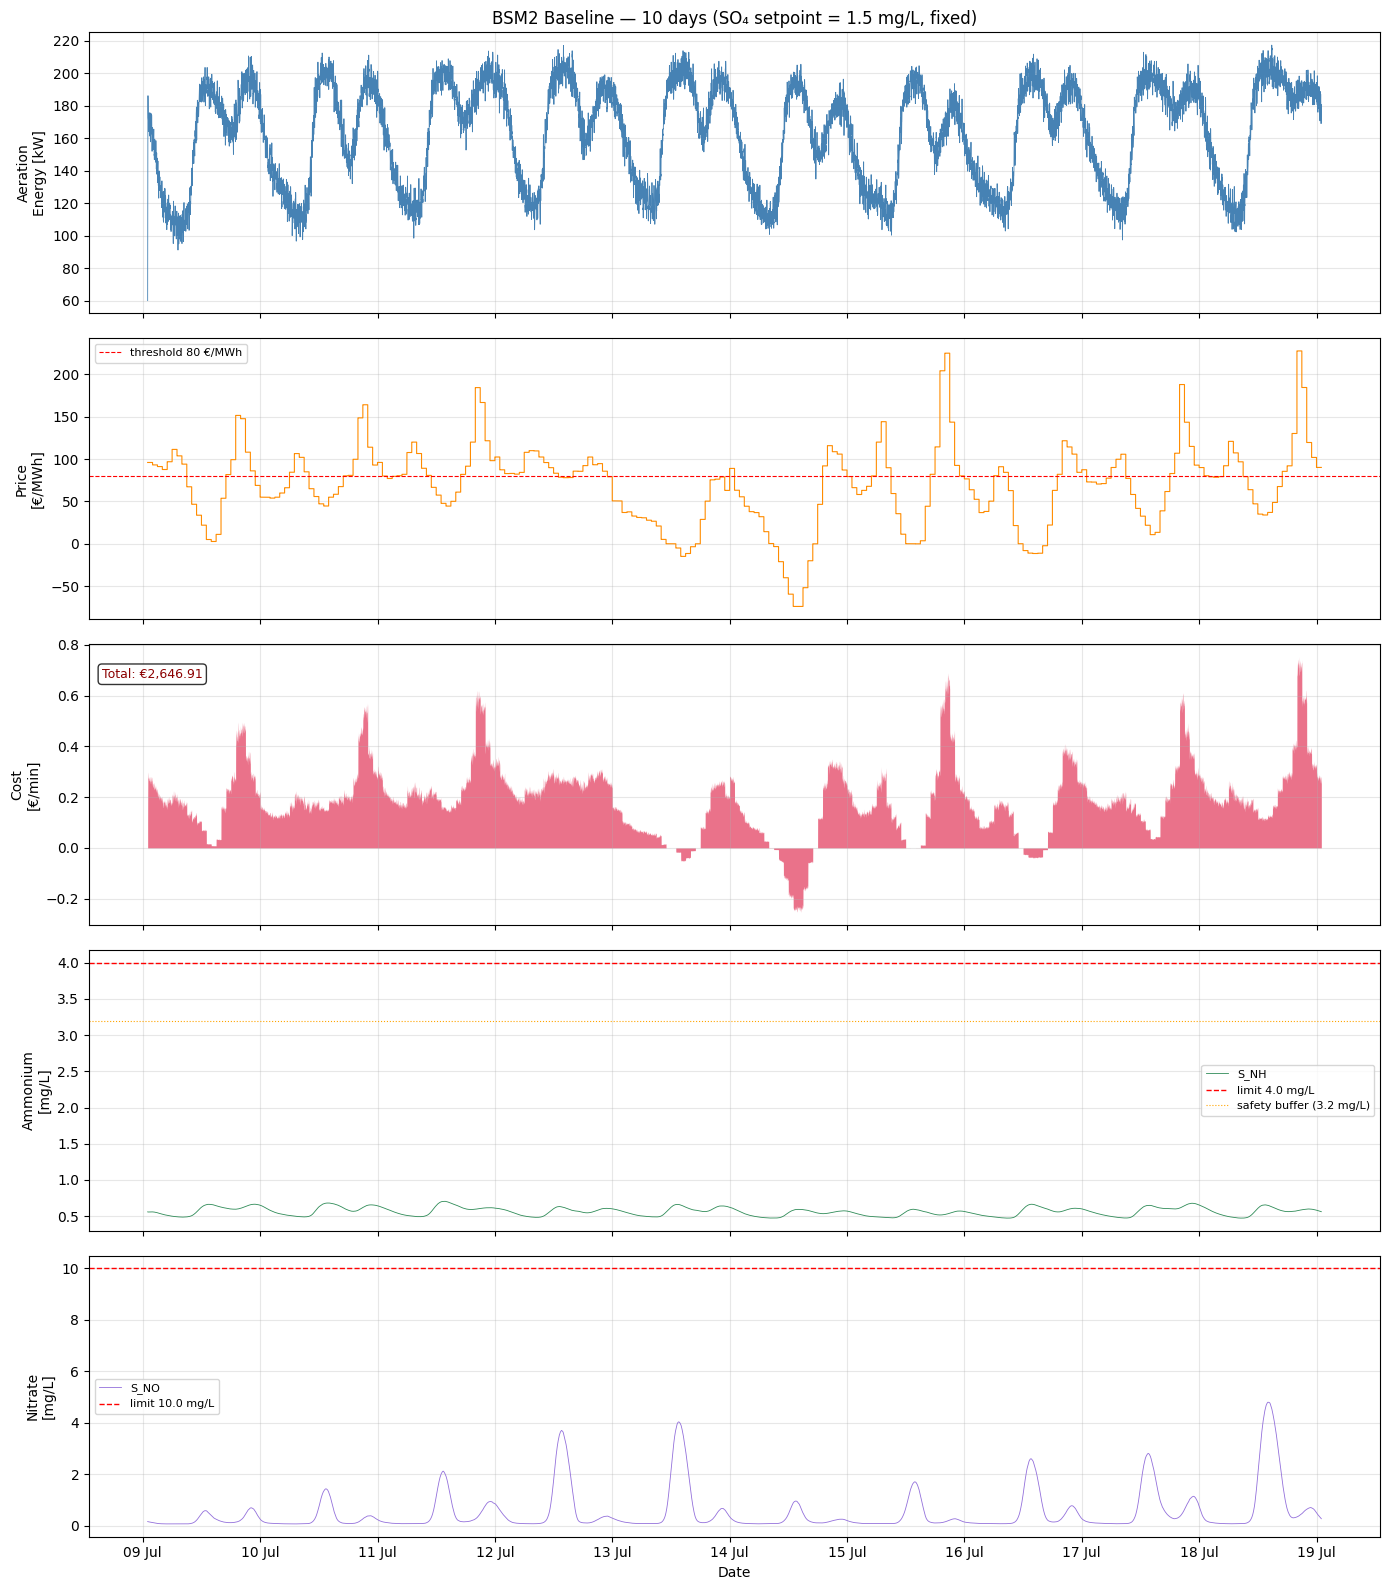

In [3]:
from bsm2_python import BSM2CL
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from parse_dayahead_prices import parse_dayahead_xml, get_price_for_timestep, price_to_cost

DAYS      = 10
STEPS     = DAYS * 24 * 60
SIM_START = pd.Timestamp("2024-07-09 01:00")

# ASM1 indices in y_out5
SO_IDX  = 8   # dissolved oxygen
SNO_IDX = 9   # nitrate
SNH_IDX = 10  # ammonium

# compliance limits (EU Urban Wastewater Treatment Directive)
SNH_LIMIT = 4.0   # mg/L
SNO_LIMIT = 10.0  # mg/L

prices  = parse_dayahead_xml("Day-ahead_prices_240709_260311_Hour.xml")
bsm2_cl = BSM2CL()

records = []
for idx, _ in enumerate(tqdm(bsm2_cl.simtime[:STEPS], desc=f"Baseline ({DAYS} days)")):
    bsm2_cl.step(idx, 1.5)
    current_dt = SIM_START + pd.Timedelta(minutes=idx)
    price      = get_price_for_timestep(prices, current_dt)
    records.append({
        "dt":    current_dt,
        "ae_kw": bsm2_cl.ae,
        "price": price,
        "cost":  price_to_cost(bsm2_cl.ae, price),
        "s_nh":  bsm2_cl.y_out5[SNH_IDX],
        "s_no":  bsm2_cl.y_out5[SNO_IDX],
    })

df = pd.DataFrame(records).set_index("dt")
df.to_pickle("sim_baseline_ae.pkl")

print(f"\n{len(df):,} steps saved.")
print(df.describe().round(3))

# --- plot ---
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

# Panel 1: aeration energy
axes[0].plot(df.index, df["ae_kw"], lw=0.6, color="steelblue")
axes[0].set_ylabel("Aeration\nEnergy [kW]")
axes[0].set_title("BSM2 Baseline — 10 days (SO₄ setpoint = 1.5 mg/L, fixed)")
axes[0].grid(True, alpha=0.3)

# Panel 2: electricity price
axes[1].step(df.index, df["price"], lw=0.8, color="darkorange", where="post")
axes[1].axhline(80, color="red", lw=0.8, ls="--", label="threshold 80 €/MWh")
axes[1].set_ylabel("Price\n[€/MWh]")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3: cost per timestep
axes[2].fill_between(df.index, df["cost"], color="crimson", alpha=0.6, lw=0)
axes[2].set_ylabel("Cost\n[€/min]")
axes[2].annotate(
    f"Total: €{df['cost'].sum():,.2f}",
    xy=(0.01, 0.88), xycoords="axes fraction",
    fontsize=9, color="darkred",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
)
axes[2].grid(True, alpha=0.3)

# Panel 4: ammonium with compliance limit
axes[3].plot(df.index, df["s_nh"], lw=0.6, color="seagreen", label="S_NH")
axes[3].axhline(SNH_LIMIT, color="red", lw=1.0, ls="--", label=f"limit {SNH_LIMIT} mg/L")
axes[3].axhline(SNH_LIMIT * 0.8, color="orange", lw=0.8, ls=":", label=f"safety buffer ({SNH_LIMIT*0.8} mg/L)")
axes[3].set_ylabel("Ammonium\n[mg/L]")
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.3)

# Panel 5: nitrate with compliance limit
axes[4].plot(df.index, df["s_no"], lw=0.6, color="mediumpurple", label="S_NO")
axes[4].axhline(SNO_LIMIT, color="red", lw=1.0, ls="--", label=f"limit {SNO_LIMIT} mg/L")
axes[4].set_ylabel("Nitrate\n[mg/L]")
axes[4].set_xlabel("Date")
axes[4].legend(fontsize=8)
axes[4].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.tight_layout()
plt.savefig("baseline_ae.png", dpi=150)
print("\nPlot saved → baseline_ae.png")

In [ ]:
from bsm2_python import BSM2CL
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from parse_dayahead_prices import parse_dayahead_xml, get_price_for_timestep, price_to_cost

DAYS      = 300
STEPS     = DAYS * 24 * 60
SIM_START = pd.Timestamp("2024-07-09 01:00")

# ASM1 indices in y_out5
SO_IDX  = 8   # dissolved oxygen
SNO_IDX = 9   # nitrate
SNH_IDX = 10  # ammonium

# compliance limits (EU Urban Wastewater Treatment Directive)
SNH_LIMIT = 4.0   # mg/L
SNO_LIMIT = 10.0  # mg/L

prices  = parse_dayahead_xml("Day-ahead_prices_240709_260311_Hour.xml")
bsm2_cl = BSM2CL()

records = []
for idx, _ in enumerate(tqdm(bsm2_cl.simtime[:STEPS], desc=f"Baseline ({DAYS} days)")):
    bsm2_cl.step(idx, 1.5)
    current_dt = SIM_START + pd.Timedelta(minutes=idx)
    price      = get_price_for_timestep(prices, current_dt)
    records.append({
        "dt":    current_dt,
        "ae_kw": bsm2_cl.ae,
        "price": price,
        "cost":  price_to_cost(bsm2_cl.ae, price),
        "s_nh":  bsm2_cl.y_out5[SNH_IDX],
        "s_no":  bsm2_cl.y_out5[SNO_IDX],
    })

df = pd.DataFrame(records).set_index("dt")
df.to_pickle("sim_baseline_ae.pkl")

print(f"\n{len(df):,} steps saved.")
print(df.describe().round(3))

# --- plot ---
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

# Panel 1: aeration energy
axes[0].plot(df.index, df["ae_kw"], lw=0.6, color="steelblue")
axes[0].set_ylabel("Aeration\nEnergy [kW]")
axes[0].set_title("BSM2 Baseline — 10 days (SO₄ setpoint = 1.5 mg/L, fixed)")
axes[0].grid(True, alpha=0.3)

# Panel 2: electricity price
axes[1].step(df.index, df["price"], lw=0.8, color="darkorange", where="post")
axes[1].axhline(80, color="red", lw=0.8, ls="--", label="threshold 80 €/MWh")
axes[1].set_ylabel("Price\n[€/MWh]")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Panel 3: cost per timestep
axes[2].fill_between(df.index, df["cost"], color="crimson", alpha=0.6, lw=0)
axes[2].set_ylabel("Cost\n[€/min]")
axes[2].annotate(
    f"Total: €{df['cost'].sum():,.2f}",
    xy=(0.01, 0.88), xycoords="axes fraction",
    fontsize=9, color="darkred",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8)
)
axes[2].grid(True, alpha=0.3)

# Panel 4: ammonium with compliance limit
axes[3].plot(df.index, df["s_nh"], lw=0.6, color="seagreen", label="S_NH")
axes[3].axhline(SNH_LIMIT, color="red", lw=1.0, ls="--", label=f"limit {SNH_LIMIT} mg/L")
axes[3].axhline(SNH_LIMIT * 0.8, color="orange", lw=0.8, ls=":", label=f"safety buffer ({SNH_LIMIT*0.8} mg/L)")
axes[3].set_ylabel("Ammonium\n[mg/L]")
axes[3].legend(fontsize=8)
axes[3].grid(True, alpha=0.3)

# Panel 5: nitrate with compliance limit
axes[4].plot(df.index, df["s_no"], lw=0.6, color="mediumpurple", label="S_NO")
axes[4].axhline(SNO_LIMIT, color="red", lw=1.0, ls="--", label=f"limit {SNO_LIMIT} mg/L")
axes[4].set_ylabel("Nitrate\n[mg/L]")
axes[4].set_xlabel("Date")
axes[4].legend(fontsize=8)
axes[4].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))

plt.tight_layout()
plt.savefig("baseline_ae_300.png", dpi=150)
print("\nPlot saved → baseline_ae_300.png")

In [ ]:
# ── Cell A ── Control parameters + compute_setpoint ──────────────────────────

import numpy as np

# DO setpoint rails [mg/L]
SO4_MIN = 0.5
SO4_MAX = 3.0

# Price thresholds [€/MWh]
PRICE_LOW  =  50.0   # below → max aeration (cheap energy)
PRICE_HIGH = 150.0   # above → min aeration (expensive energy)

# NH compliance & safety [mg/L]
SNH_LIMIT      = 4.0   # regulatory hard limit
SNH_SAFETY     = 3.2   # 80% of limit — start proportional ramp
SNH_FORCE_HIGH = 3.6   # 90% of limit — emergency: force max DO

# Nitrate compliance [mg/L]
SNO_LIMIT = 10.0


def compute_setpoint(price: float, s_nh: float) -> float:
    """
    Price-responsive DO setpoint with NH safety cascade.

    Low price  → high DO setpoint (build nitrification buffer).
    High price → low DO setpoint (save energy, spend buffer).
    NH override: if ammonium approaches compliance limit, force aeration
    regardless of price.

    Parameters
    ----------
    price : float   Electricity price [€/MWh]
    s_nh  : float   Effluent ammonium from previous timestep [mg/L]

    Returns
    -------
    float  DO setpoint for bsm2_cl.step() [mg/L]
    """
    # 1. Price-based base setpoint (linear interpolation)
    if price <= PRICE_LOW:
        sp = SO4_MAX
    elif price >= PRICE_HIGH:
        sp = SO4_MIN
    else:
        frac = (price - PRICE_LOW) / (PRICE_HIGH - PRICE_LOW)
        sp = SO4_MAX - frac * (SO4_MAX - SO4_MIN)

    # 2. NH safety cascade (overrides price signal upward)
    if s_nh >= SNH_FORCE_HIGH:
        sp = SO4_MAX                               # emergency: ignore price
    elif s_nh >= SNH_SAFETY:
        excess = (s_nh - SNH_SAFETY) / (SNH_FORCE_HIGH - SNH_SAFETY)
        sp = sp + excess * (SO4_MAX - sp)          # proportional ramp

    return float(np.clip(sp, SO4_MIN, SO4_MAX))


# Quick sanity check
print("Setpoint at  30 €/MWh, SNH=1.0:", compute_setpoint( 30, 1.0), "mg/L  (expect 3.0)")
print("Setpoint at 100 €/MWh, SNH=1.0:", compute_setpoint(100, 1.0), "mg/L  (expect 1.75)")
print("Setpoint at 200 €/MWh, SNH=1.0:", compute_setpoint(200, 1.0), "mg/L  (expect 0.5)")
print("Setpoint at 200 €/MWh, SNH=3.4:", compute_setpoint(200, 3.4), "mg/L  (expect ~1.0, safety ramp)")
print("Setpoint at 200 €/MWh, SNH=3.7:", compute_setpoint(200, 3.7), "mg/L  (expect 3.0, emergency)")

In [ ]:
# ── Cell B ── 300-day controlled simulation ───────────────────────────────────

from bsm2_python import BSM2CL
from tqdm import tqdm
import pandas as pd
from parse_dayahead_prices import parse_dayahead_xml, get_price_for_timestep, price_to_cost

DAYS      = 300
STEPS     = DAYS * 24 * 60
SIM_START = pd.Timestamp("2024-07-09 01:00")

SNH_IDX = 10  # ammonium index in y_out5
SNO_IDX = 9   # nitrate index in y_out5

prices  = parse_dayahead_xml("Day-ahead_prices_240709_260311_Hour.xml")
bsm2_cl = BSM2CL()

records = []
for idx, _ in enumerate(tqdm(bsm2_cl.simtime[:STEPS], desc=f"Controlled ({DAYS} days)")):
    current_dt = SIM_START + pd.Timedelta(minutes=idx)
    price      = get_price_for_timestep(prices, current_dt)

    # Read state BEFORE step (measure → compute → actuate)
    s_nh_now = float(bsm2_cl.y_out5[SNH_IDX])
    sp       = compute_setpoint(price, s_nh_now)

    bsm2_cl.step(idx, sp)

    records.append({
        "dt":      current_dt,
        "ae_kw":   bsm2_cl.ae,
        "price":   price,
        "cost":    price_to_cost(bsm2_cl.ae, price),
        "s_nh":    float(bsm2_cl.y_out5[SNH_IDX]),
        "s_no":    float(bsm2_cl.y_out5[SNO_IDX]),
        "so4_set": sp,
    })

df_ctrl = pd.DataFrame(records).set_index("dt")
df_ctrl.to_pickle("sim_controlled_ae.pkl")

print(f"\n{len(df_ctrl):,} steps saved → sim_controlled_ae.pkl")
print(df_ctrl.describe().round(3))

In [ ]:
# ── Cell C ── Summary statistics ──────────────────────────────────────────────

import pandas as pd

df_base = pd.read_pickle("sim_baseline_ae.pkl")
df_ctrl = pd.read_pickle("sim_controlled_ae.pkl")

# Align on common index (handles any length difference)
idx_common  = df_base.index.intersection(df_ctrl.index)
df_base_aln = df_base.loc[idx_common]
df_ctrl_aln = df_ctrl.loc[idx_common]

# Cost
cost_base = df_base_aln["cost"].sum()
cost_ctrl = df_ctrl_aln["cost"].sum()
savings   = cost_base - cost_ctrl
savings_p = 100.0 * savings / cost_base

# Compliance violations (minutes above limit)
viol_snh_base = (df_base_aln["s_nh"] >= SNH_LIMIT).sum()
viol_sno_base = (df_base_aln["s_no"] >= SNO_LIMIT).sum()
viol_snh_ctrl = (df_ctrl_aln["s_nh"] >= SNH_LIMIT).sum()
viol_sno_ctrl = (df_ctrl_aln["s_no"] >= SNO_LIMIT).sum()

print("=" * 62)
print("  PRICE-RESPONSIVE CONTROL — 300-DAY SUMMARY")
print("=" * 62)
print(f"  {'':35s}  {'Baseline':>10}  {'Controlled':>10}")
print(f"  {'-'*57}")
print(f"  {'Total aeration cost [€]':35s}  {cost_base:>10,.0f}  {cost_ctrl:>10,.0f}")
print(f"  {'Savings [€ / %]':35s}  {'':>10}  {savings:>+8,.0f} ({savings_p:+.1f}%)")
print()
print(f"  COMPLIANCE VIOLATIONS (minutes ≥ limit)")
print(f"  {'SNH ≥ 4.0 mg/L [min]':35s}  {viol_snh_base:>10,}  {viol_snh_ctrl:>10,}")
print(f"  {'SNO ≥ 10.0 mg/L [min]':35s}  {viol_sno_base:>10,}  {viol_sno_ctrl:>10,}")
print("=" * 62)

In [ ]:
# ── Cell D ── 6-panel comparison plot ─────────────────────────────────────────

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df_base = pd.read_pickle("sim_baseline_ae.pkl")
df_ctrl = pd.read_pickle("sim_controlled_ae.pkl")

# Resample to hourly for plotting (432k points → 7.2k)
rs_base = df_base.resample("60min").mean()
rs_ctrl = df_ctrl.resample("60min").mean()

# Cumulative cost (hourly snapshot)
cum_base = df_base["cost"].cumsum().resample("60min").last()
cum_ctrl = df_ctrl["cost"].cumsum().resample("60min").last()

# DO setpoint hourly stats
sp_mean = df_ctrl["so4_set"].resample("60min").mean()
sp_min  = df_ctrl["so4_set"].resample("60min").min()
sp_max  = df_ctrl["so4_set"].resample("60min").max()

# Pre-compute savings for annotation
savings_eur = df_base["cost"].sum() - df_ctrl["cost"].sum()
savings_pct = 100.0 * savings_eur / df_base["cost"].sum()

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    3, 2, figsize=(18, 14), sharex=True,
    gridspec_kw={"hspace": 0.38, "wspace": 0.28},
)
fig.suptitle(
    "BSM2 Price-Responsive Control vs Fixed-Setpoint Baseline — 300 Days",
    fontsize=13, fontweight="bold", y=0.995,
)

C_BASE  = "steelblue"
C_CTRL  = "darkorange"
C_LIMIT = "red"
C_SAFE  = "goldenrod"

# (0,0) Aeration energy
ax = axes[0, 0]
ax.plot(rs_base.index, rs_base["ae_kw"], lw=0.7, color=C_BASE,  label="Baseline (1.5 mg/L fixed)")
ax.plot(rs_ctrl.index, rs_ctrl["ae_kw"], lw=0.7, color=C_CTRL,  label="Controlled", alpha=0.85)
ax.set_ylabel("Aeration Energy [kW]")
ax.set_title("Aeration Energy", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

# (0,1) Electricity price
ax = axes[0, 1]
ax.step(rs_base.index, rs_base["price"], lw=0.7, color="dimgray", where="post", label="DE/LU day-ahead")
ax.axhline(PRICE_LOW,  color=C_CTRL,  lw=0.9, ls="--", label=f"PRICE_LOW  {PRICE_LOW:.0f} €/MWh")
ax.axhline(PRICE_HIGH, color=C_LIMIT, lw=0.9, ls="--", label=f"PRICE_HIGH {PRICE_HIGH:.0f} €/MWh")
ax.set_ylabel("Price [€/MWh]")
ax.set_title("Electricity Price Signal", fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.25)

# (1,0) Cumulative cost
ax = axes[1, 0]
ax.plot(cum_base.index, cum_base / 1e3, lw=1.0, color=C_BASE, label="Baseline")
ax.plot(cum_ctrl.index, cum_ctrl / 1e3, lw=1.0, color=C_CTRL, label="Controlled")
ax.fill_between(cum_base.index, cum_ctrl / 1e3, cum_base / 1e3,
                color=C_CTRL, alpha=0.15, label="Savings area")
ax.annotate(
    f"Savings: €{savings_eur:,.0f}  ({savings_pct:.1f} %)",
    xy=(0.97, 0.05), xycoords="axes fraction", ha="right", fontsize=9,
    color=C_CTRL, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=C_CTRL, alpha=0.85),
)
ax.set_ylabel("Cumulative Cost [k€]")
ax.set_title("Cumulative Aeration Cost", fontsize=10)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, alpha=0.25)

# (1,1) Effluent ammonium
ax = axes[1, 1]
ax.plot(rs_base.index, rs_base["s_nh"], lw=0.7, color=C_BASE, label="Baseline")
ax.plot(rs_ctrl.index, rs_ctrl["s_nh"], lw=0.7, color=C_CTRL, label="Controlled", alpha=0.85)
ax.axhline(SNH_LIMIT,      color=C_LIMIT, lw=1.0, ls="--", label=f"Limit {SNH_LIMIT} mg/L")
ax.axhline(SNH_SAFETY,     color=C_SAFE,  lw=0.8, ls=":",  label=f"Safety {SNH_SAFETY} mg/L")
ax.axhline(SNH_FORCE_HIGH, color="tomato", lw=0.8, ls=":", label=f"Force-high {SNH_FORCE_HIGH} mg/L")
ax.set_ylabel("S_NH [mg/L]")
ax.set_title("Effluent Ammonium", fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.25)

# (2,0) Effluent nitrate
ax = axes[2, 0]
ax.plot(rs_base.index, rs_base["s_no"], lw=0.7, color=C_BASE, label="Baseline")
ax.plot(rs_ctrl.index, rs_ctrl["s_no"], lw=0.7, color=C_CTRL, label="Controlled", alpha=0.85)
ax.axhline(SNO_LIMIT, color=C_LIMIT, lw=1.0, ls="--", label=f"Limit {SNO_LIMIT} mg/L")
ax.set_ylabel("S_NO [mg/L]")
ax.set_title("Effluent Nitrate", fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.25)

# (2,1) Commanded DO setpoint
ax = axes[2, 1]
ax.fill_between(sp_mean.index, sp_min, sp_max,
                color=C_CTRL, alpha=0.2, label="Setpoint range (min–max/hr)")
ax.plot(sp_mean.index, sp_mean, lw=0.7, color=C_CTRL, label="Mean setpoint/hr")
ax.axhline(1.5,     color=C_BASE, lw=1.0, ls="--", label="Baseline fixed 1.5 mg/L")
ax.axhline(SO4_MIN, color="gray", lw=0.6, ls=":",  label=f"SO4_MIN {SO4_MIN}")
ax.axhline(SO4_MAX, color="gray", lw=0.6, ls=":",  label=f"SO4_MAX {SO4_MAX}")
ax.set_ylabel("DO Setpoint [mg/L]")
ax.set_title("Commanded DO Setpoint", fontsize=10)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.25)

# Shared x-axis formatting
for row in axes:
    for ax in row:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%Y"))
        ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.savefig("comparison_controlled_vs_baseline.png", dpi=150, bbox_inches="tight")
print("Plot saved → comparison_controlled_vs_baseline.png")
plt.show()